# **Perguntas a responder:**

1. Os 5 órgãos com maior custo total?
2. Os 3 destinos com maior custo médio por viagem?
3. A viagem de maior duração e seu custo total?
4. Qual o tipo de pagamento com maior valor médio?
5. Qual o meio de transporte mais usado nos trechos?
6. Qual UF de destino aparece em mais trechos?
7. Qual órgão pagou mais no total?

### **Importações e Criação de funções**


In [4]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))

from database import banco
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

PASTA_RAIZ = Path.cwd().parent
PASTA_SQL_GOLD = PASTA_RAIZ / "sql" / "gold"

lista_perguntas = [
    ("pergunta_1", "top5_orgaos_custo_total"),
    ("pergunta_2", "top3_destinos_custo_medio"),
    ("pergunta_3", "viagem_maior_duracao"),
    ("pergunta_4", "tipo_pagamento_valor_medio"),
    ("pergunta_5", "meio_transporte_utilizacao"),
    ("pergunta_6", "destino_uf_frequencia"),
    ("pergunta_7", "orgaos_pagadores_custo_total"),
]
# Ajustando a visuaçização do Pandas, devido aos valores serem altos e acabarem dificultando a visualização
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [8]:
def carregar_sql(caminho):
    with open(caminho, "r", encoding="utf-8") as arquivo:
        return arquivo.read()

In [6]:
def criar_gold_view(conexao, nome_tabela, sql):

    print(f"Criando a GOLD da tabela gold_{nome_tabela}")
    banco.executar(conexao, f"DROP TABLE IF EXISTS gold_{nome_tabela}")
    banco.executar(conexao, f"CREATE TABLE gold_{nome_tabela} AS {sql}")

    print(f"Criando a VIEW da tabela {nome_tabela}")
    banco.executar(conexao, f"DROP VIEW IF EXISTS vw_{nome_tabela}")
    banco.executar(conexao, f"CREATE VIEW vw_{nome_tabela} AS {sql}")

In [7]:
def analisar(pergunta):
    conexao = None

    try:
        conexao = banco.conectar()
        caminho_sql = PASTA_SQL_GOLD / f"{lista_perguntas[pergunta-1][0]}.sql"
        sql = carregar_sql(caminho_sql)
        df = pd.read_sql(sql, conexao)

    except Exception as erro:
        print("[ERRO] Algo deu errado:", erro)
        raise

    finally:
        if conexao:
            conexao.close()

    return df

# **Início das análises**

### Pergunta_1: Os 5 órgãos com maior custo total?

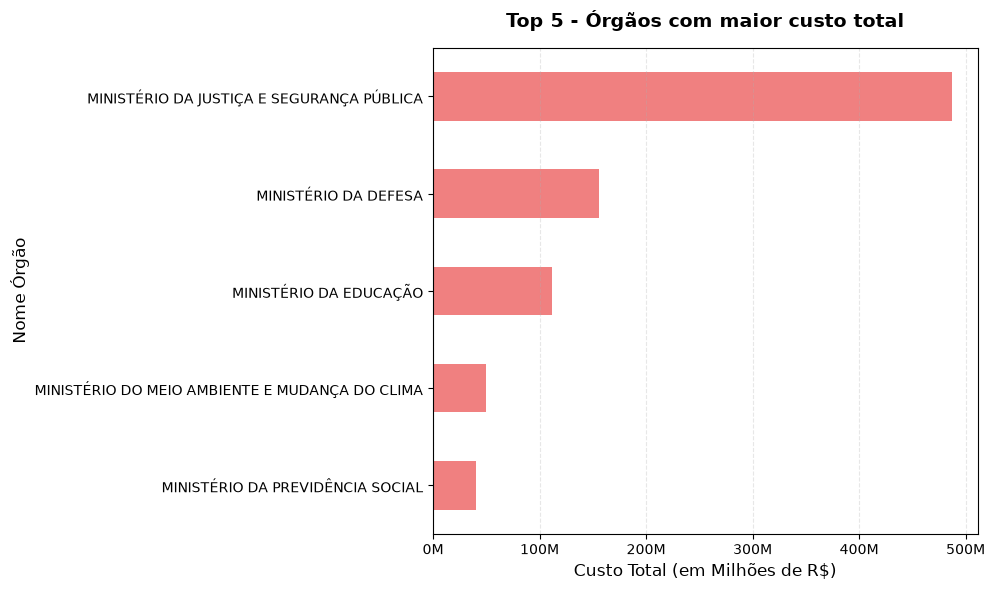

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,nome_orgao_superior,custo_total
0,MINISTÉRIO DA JUSTIÇA E SEGURANÇA PÚBLICA,"486,933,121.65"
1,MINISTÉRIO DA DEFESA,"156,070,304.49"
2,MINISTÉRIO DA EDUCAÇÃO,"111,291,349.34"
3,MINISTÉRIO DO MEIO AMBIENTE E MUDANÇA DO CLIMA,"49,697,710.16"
4,MINISTÉRIO DA PREVIDÊNCIA SOCIAL,"40,417,309.06"


In [ ]:
df = analisar(1)

df["custo_total"] = df["custo_total"].astype(str).str.replace(",", "")
df["custo_total"] = pd.to_numeric(df["custo_total"])
df = df.sort_values(by="custo_total", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
df.plot.barh(
    x="nome_orgao_superior", y="custo_total", ax=ax, color="lightcoral", legend=False
)

def milhões_formatter(x, pos):
    return f"{x*1e-6:.0f}M"

ax.xaxis.set_major_formatter(ticker.FuncFormatter(milhões_formatter))
ax.set_title(
    "Top 5 - Órgãos com maior custo total", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Custo Total (em Milhões de R$)", fontsize=12)
ax.set_ylabel("Nome Órgão", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="custo_total", ascending=False).head()

### Pergunta_2: Os 3 destinos com maior custo médio por viagem?

In [10]:
try:
    conexao = banco.conectar()
    caminho_sql = PASTA_SQL_GOLD / f"{lista_perguntas[1][0]}.sql"
    sql = carregar_sql(caminho_sql)
    criar_gold_view(conexao, lista_perguntas[1][1], sql)

except Exception as erro:
    print("[ERRO] Algo deu errado:", erro)
    raise

finally:
    if conexao:
        conexao.close()
df = analisar(2)
df

Criando a GOLD da tabela gold_top3_destinos_custo_medio
Criando a VIEW da tabela top3_destinos_custo_medio


,destino,custo_medio
0,TEJUPÁ/SÃO PAULO,"115,175.00"
1,CHAVANTES/SÃO PAULO,"114,557.01"
2,TEOLÂNDIA/BAHIA,"109,322.50"


### Pergunta_3: A viagem de maior duração e seu custo total?


In [161]:
df = analisar(3)
df

,id_viagem,nome_viajante,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,2025-01-13,2026-01-31,383,0.00


### Pergunta_4: Qual o tipo de pagamento com maior valor médio?


In [162]:
df = analisar(4)
df

,tipo_pagamento,valor_medio
0,DIÁRIAS,"2,078.28"


### Pergunta_5: Qual o meio de transporte mais usado nos trechos?


In [163]:
df = analisar(5)
df

,meio_transporte,qtde_viagens
0,VEÍCULO OFICIAL,386424


### Pergunta_6: Qual UF de destino aparece em mais trechos?


In [164]:
df = analisar(6)
df

,destino_uf,quantidade
0,SÃO PAULO,82722


### Pergunta_7: Qual órgão pagou mais no total?

In [165]:
df = analisar(7)
df

,nome_orgao_pagador,total_pago
0,FUNDO NACIONAL DE SEGURANÇA PÚBLICA,"278,481,047.89"
